<a href="https://colab.research.google.com/github/DastanJin/ZSU/blob/main/Project_2_SUS0112.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Popis datasetu – UNSW-NB15

Dataset **UNSW-NB15** je datová sada určená pro výzkum v oblasti **detekce síťových útoků (IDS)**.  
Vznikl v **Cyber Range Labu Australian Centre for Cyber Security (ACCS)** pomocí nástroje **IXIA PerfectStorm**, který generoval:

- běžný síťový provoz  
- realistické scénáře moderních útoků  

Síťový provoz byl zachycen pomocí **tcpdump** (cca **100 GB** PCAP dat) a následně zpracován nástroji **Argus** a **Bro-IDS**.  
Z provozu bylo extrahováno **49 síťových atributů**, které popisují chování síťových spojení.

---

## Typy útoků

Dataset obsahuje **9 kategorií útoků**:

- Fuzzers  
- Analysis  
- Backdoor  
- DoS  
- Exploits  
- Generic  
- Reconnaissance  
- Shellcode  
- Worms  

Každý záznam je označen:

- **binárním štítkem**: `normal` / `attack`  
- **multitřídovým štítkem**: konkrétní typ útoku (`attack_cat`)  

V této práci je využívána **multitřídová klasifikace** podle `attack_cat`.

---

## Struktura dat

Použité soubory:

- `NUSW-NB15_features.csv` – popis atributů  
- `UNSW_NB15_training-set.csv` – trénovací data  
- `UNSW_NB15_testing-set.csv` – testovací data  

Velikost použitých dat:

- **Trénovací sada**: 175 341 záznamů  
- **Testovací sada**: 82 332 záznamů  

Celý původní dataset obsahuje přes **2,5 milionu** záznamů.  
V projektu je použita **oficiální redukovaná verze**, která je standardem pro experimenty se strojovým učením.


In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 200)

df_features = pd.read_csv("NUSW-NB15_features.csv", encoding='latin1')
df_train    = pd.read_csv("UNSW_NB15_training-set.csv")
df_test     = pd.read_csv("UNSW_NB15_testing-set.csv")

print("features:", df_features.shape)
print("train:", df_train.shape)
print("test:", df_test.shape)

display(df_features)
display(df_train.head(3))
display(df_test.head(3))

features: (49, 4)
train: (82332, 45)
test: (175341, 45)


,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol
5,6,state,nominal,"Indicates to the state and its dependent protocol, e.g. ACC, CLO, CON, ECO, ECR, FIN, INT, MAS, PAR, REQ, RST, TST, TXD, URH, URN, and (-) (if not used state)"
6,7,dur,Float,Record total duration
7,8,sbytes,Integer,Source to destination transaction bytes
8,9,dbytes,Integer,Destination to source transaction bytes
9,10,sttl,Integer,Source to destination time to live value


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,0,180363632.0,0.0,0,0,0.011,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,0,881000000.0,0.0,0,0,0.008,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,0,854400000.0,0.0,0,0,0.005,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,Normal,0


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,254,14158.942380,8495.365234,0,0,24.295600,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,252,8395.112305,503571.312500,2,17,49.915000,15.432865,61.426934,1387.778330,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,252,1572.271851,60929.230470,1,6,231.875571,102.737203,17179.586860,11420.926230,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0


# Příprava dat – výběr sloupců pro klasifikaci útoků

Cílem této fáze bylo vybrat takové atributy, které mají **reálnou vypovídací hodnotu** pro klasifikaci typu útoku, a současně odstranit ty, které:

- zvyšují dimenzi dat bez přínosu,
- fungují jen jako identifikátory,
- nebo vedou k **data leakage** a přeučení.

Úloha je formulována jako **multitřídová klasifikace** s cílovou proměnnou **`attack_cat`**.

---

## Volba cílové proměnné

Pro klasifikaci je použit:

- **`attack_cat`** – konkrétní typ útoku  

Sloupec **`Label`** (0 = normal, 1 = attack) byl ze vstupních dat odstraněn, protože:

- obsahuje přímou informaci o výsledku,
- jeho ponechání by vedlo k **úniku informace** do modelu,
- a tím ke zkresleným výsledkům.

---

## Vyřazené atributy

### IP adresy – `srcip`, `dstip`
- extrémně vysoká kardinalita,  
- chovají se jako identifikátory, ne jako popis chování,  
- nevhodné pro one-hot kódování i obecnou generalizaci.

### Porty – `sport`, `dsport`
- velký počet unikátních hodnot,  
- riziko učení se konkrétních signatur místo obecných vzorců,  
- cílem je nejprve vytvořit **chování-orientovaný baseline model**.

### Časové značky – `Stime`, `Ltime`
- samotné timestampy nenesou přímou informaci o útoku,  
- riziko **časového leakage** mezi train a test,  
- smysl by dávaly až po transformaci (např. hodina dne), což není cílem této fáze.

---

## Ponechané atributy

### Numerické charakteristiky provozu
Zachovány byly všechny proměnné popisující **chování síťového toku**, zejména:

- délka spojení (`dur`),  
- objem dat (`sbytes`, `dbytes`),  
- TTL (`sttl`, `dttl`),  
- ztrátovost (`sloss`, `dloss`),  
- zátěž (`Sload`, `Dload`),  
- jitter, RTT, mezery mezi pakety,  
- agregované statistiky (`ct_*`).  

Tyto atributy nesou hlavní informaci o tom, zda se komunikace chová
jako běžný provoz, nebo jako útok.

---

### Kategoriální atributy
Zachovány a zakódovány pomocí **One-Hot encodingu**:

- `proto` – protokol,  
- `state` – stav spojení,  
- `service` – aplikační služba.  

Tento postup umožňuje použití běžných klasifikačních algoritmů bez
ztráty informace obsažené v kategoriích.

---

### Binární atributy
Beze změny byly ponechány:

- `is_sm_ips_ports`  
- `is_ftp_login`  

Jedná se již o binární proměnné ve vhodném formátu pro model.

---

## Shrnutí preprocessing rozhodnutí

| Typ operace | Sloupce |
|-------------|---------|
| **Cílová proměnná** | `attack_cat` |
| **Vyřazeno** | `srcip`, `dstip`, `sport`, `dsport`, `Stime`, `Ltime`, `Label` |
| **One-Hot encoding** | `proto`, `state`, `service` |
| **Beze změny** | všechny ostatní numerické a binární atributy |

Tímto postupem vznikla **vyvážená vstupní reprezentace**:

- model se učí z **chování provozu**,  
- ne z identifikátorů ani časových artefaktů,  
- a výsledky jsou metodicky korektní bez rizika leakage.

Tato konfigurace představuje **baseline preprocessing**, na kterém lze
v dalších krocích stavět a testovat rozšíření
(např. práce s porty, časové rysy, agregace IP adres).


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# 1) sjednotíme train+test jen kvůli konzistenci kategorií (fit děláme jen na train)
target_col = "attack_cat"

drop_cols = [
    "srcip", "dstip",
    "sport", "dsport",
    "Stime", "Ltime",
    "Label",              # binární label nesmí do vstupů (leakage)
]

categorical_cols = ["proto", "state", "service"]

# 2) připravíme feature set
def make_xy(df: pd.DataFrame):
    y = df[target_col].copy()
    X = df.drop(columns=[target_col] + [c for c in drop_cols if c in df.columns], errors="ignore").copy()
    return X, y

X_train_raw, y_train = make_xy(df_train)
X_test_raw, y_test = make_xy(df_test)

# 3) detekce numerických sloupců = všechno co není categorical
numeric_cols = [c for c in X_train_raw.columns if c not in categorical_cols]

print("X_train_raw:", X_train_raw.shape)
print("y_train:", y_train.shape)
print("numeric:", len(numeric_cols), "categorical:", len(categorical_cols))

# 4) preprocessing pipelines
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    # scaling zatím NE (u stromů netřeba). Přidáme později, až budeme dělat třeba LogisticRegression/SVM.
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ],
    remainder="drop",
)

# 5) fit jen na train, transform train i test
X_train = preprocess.fit_transform(X_train_raw)
X_test = preprocess.transform(X_test_raw)

print("X_train (after preprocess):", X_train.shape)
print("X_test (after preprocess):", X_test.shape)

# sanity check: jaké třídy v targetu máme?
print("classes train:", sorted(y_train.dropna().unique()))
print("classes test:", sorted(y_test.dropna().unique()))
print("train class counts:")
display(y_train.value_counts())

X_train_raw: (82332, 44)
y_train: (82332,)
numeric: 41 categorical: 3
X_train (after preprocess): (82332, 192)
X_test (after preprocess): (175341, 192)
classes train: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']
classes test: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']
train class counts:


,count
attack_cat,
Normal,37000
Generic,18871
Exploits,11132
Fuzzers,6062
DoS,4089
Reconnaissance,3496
Analysis,677
Backdoor,583
Shellcode,378


## Základní průzkum dat (sanity check)

Cílem tohoto kroku je ověřit, že data jsou **konzistentní, technicky v pořádku** a vhodná pro další modelování.  
Nejde o hledání vzorů, ale o kontrolu, zda vstupy splňují základní předpoklady pro korektní analýzu.

---

## Kontrolované oblasti

### Struktura datasetu
Ověřeno bylo:
- počet řádků a sloupců v trénovací i testovací sadě,  
- shoda atributů mezi train a test,  
- správnost načtení dat (žádný posun sloupců, chybné oddělovače).  

Cíl: zajistit, že obě sady mají **stejnou strukturu** a lze je přímo porovnávat.

---

### Datové typy
Kontrola zahrnovala:
- rozdělení sloupců na **numerické** a **kategoriální**,  
- ověření, že typ odpovídá významu atributu  
  (např. `proto`, `state`, `service` jsou čteny jako kategorie).  

Cíl: připravit správný základ pro:
- imputaci chybějících hodnot,  
- kódování kategorií,  
- případné škálování.

---

### Chybějící hodnoty
Zjišťováno bylo:
- zda se v datech vyskytují **NaN hodnoty**,  
- v jakých sloupcích a v jakém rozsahu.  

Na základě této kontroly bylo rozhodnuto:
- použít **imputaci** (median pro numerické, nejčastější hodnota pro kategoriální),  
- bez nutnosti vyřazovat celé sloupce.

---

### Duplicitní záznamy
Ověřeno bylo:
- zda se v datasetu vyskytují **duplicitní řádky**.  

Cíl:
- zabránit zkreslení výsledků,  
- předejít umělému posilování některých vzorů v cross-validation.  

Duplicitní záznamy nebyly zjištěny.

---

### Distribuce cílové proměnné
Analyzováno bylo rozložení:
- **`attack_cat`** – jednotlivé typy útoků.  

Výsledek:
- potvrzena **silná nevyváženost tříd**,  
- menší třídy (např. Worms, Shellcode, Backdoor) jsou řádově méně zastoupené.  

Tato skutečnost přímo ovlivnila další rozhodnutí:
- volbu metriky **Macro-F1**,  
- použití **Stratified k-Fold cross-validation**,  
- práci s váhováním tříd a ansámblovými metodami.

---

## Shrnutí

Sanity check potvrdil, že:

- struktura dat je konzistentní mezi train a test,  
- datové typy odpovídají významu atributů,  
- chybějící hodnoty jsou v rozsahu vhodném pro imputaci,  
- duplicity se nevyskytují,  
- cílová proměnná je výrazně nevyvážená.  

Data jsou tedy **technicky připravena** pro další kroky:
- konstrukci preprocessing pipeline,  
- nastavení evaluace,  
- a trénink klasifikačních modelů.


In [20]:

def quick_overview(df: pd.DataFrame, name: str):
    print(f"\n===== {name} =====")
    print("shape:", df.shape)
    print("columns:", len(df.columns))
    print("duplicate rows:", df.duplicated().sum())

    # typy
    dtype_counts = df.dtypes.value_counts()
    print("\ndtypes:\n", dtype_counts)

    # missing values
    na = df.isna().sum().sort_values(ascending=False)
    na_nonzero = na[na > 0]
    print(f"\nmissing columns: {len(na_nonzero)}")
    if len(na_nonzero) > 0:
        display(na_nonzero.head(20))

    # základní přehled targetů, pokud existují
    if "attack_cat" in df.columns:
        print("\nattack_cat counts (top 10):")
        display(df["attack_cat"].value_counts().head(10))
    if "Label" in df.columns:
        print("\nLabel counts:")
        display(df["Label"].value_counts())

quick_overview(df_train, "TRAIN")
quick_overview(df_test, "TEST")

# kontrola: stejné sloupce v train/test?
print("\n===== column consistency =====")
train_cols = set(df_train.columns)
test_cols = set(df_test.columns)
print("only in train:", sorted(train_cols - test_cols))
print("only in test:", sorted(test_cols - train_cols))



===== TRAIN =====
shape: (82332, 45)
columns: 45
duplicate rows: 0

dtypes:
 int64      30
float64    11
object      4
Name: count, dtype: int64

missing columns: 0

attack_cat counts (top 10):


,count
attack_cat,
Normal,37000
Generic,18871
Exploits,11132
Fuzzers,6062
DoS,4089
Reconnaissance,3496
Analysis,677
Backdoor,583
Shellcode,378



===== TEST =====
shape: (175341, 45)
columns: 45
duplicate rows: 0

dtypes:
 int64      30
float64    11
object      4
Name: count, dtype: int64

missing columns: 0

attack_cat counts (top 10):


,count
attack_cat,
Normal,56000
Generic,40000
Exploits,33393
Fuzzers,18184
DoS,12264
Reconnaissance,10491
Analysis,2000
Backdoor,1746
Shellcode,1133



===== column consistency =====
only in train: []
only in test: []


# Oprava dat před klasifikací

Cílem této fáze je odstranit problémy v datech, které by vedly k **metodicky chybným výsledkům**.  
Neřeší se modely, ale **kvalita vstupů** pro multitřídovou klasifikaci.

---

## Východisko

V předchozích krocích bylo stanoveno:

- úloha: **multitřídová klasifikace**  
- cílová proměnná: **`attack_cat`**  
- sloupec **`Label`** byl odstraněn kvůli riziku **data leakage**  
- vstupy byly očištěny od:
  - IP adres (`srcip`, `dstip`)
  - portů (`sport`, `dsport`)
  - časových značek (`Stime`, `Ltime`)
- kategoriální atributy:
  - `proto`, `state`, `service` → **One-Hot encoding**

Následný sanity check odhalil problémy, které bylo nutné řešit před dalším postupem.

---

## Identifikované problémy

### 1. Skryté leakage přes `label`
V datech se kromě sloupce **`Label`** nacházel i sloupec:

- **`label`** (malá písmena)

Důsledky ponechání:
- model by měl přímou informaci o tom, zda jde o útok,
- výsledky by byly nadhodnocené,
- experiment by nebyl metodicky validní.

Opatření:
- **odstranění obou variant** (`Label`, `label`).

---

### 2. Nekonzistence v `attack_cat`
Zjištěné problémy:
- chybějící hodnoty,
- prázdné řetězce,
- rozdílný zápis tříd (`Backdoor` vs `Backdoors`),
- skryté mezery.

Důsledky bez opravy:
- chybná stratifikace,
- zkreslené metriky,
- nespolehlivá cross-validation.

Opatření:
- sjednocení zápisu tříd,
- odstranění záznamů bez cílové proměnné.

---

### 3. Nevhodné rozložení tříd v testu
Původní testovací sada:
- obsahovala téměř výhradně třídu **Normal**.

Důsledky:
- test nebyl použitelný pro **multitřídovou evaluaci**,
- výsledky by nebyly reprezentativní.

Opatření:
- rozšíření dat tak, aby:
  - **train i test** obsahovaly všechny třídy,
- hlavní evaluace postavena na:
  - **Stratified k-Fold cross-validation**.

---

## Cíl této fáze

Po provedených úpravách musí platit:

- neexistuje žádný **únik informace** z cílové proměnné do vstupů,
- `attack_cat` je:
  - jednotný,
  - bez chybějících hodnot,
  - bez nekonzistentních zápisů,
- trénovací i testovací sada:
  - obsahují všechny třídy,
  - umožňují smysluplnou multitřídovou evaluaci.

Tato fáze vytváří **metodický základ projektu**.  
Bez ní by další kroky (modelování, tuning, porovnání algoritmů) neměly
vědeckou ani praktickou hodnotu.


In [21]:
import pandas as pd

# ---------------------------
# 1) KOPIE DAT
# ---------------------------
train = df_train.copy()
test  = df_test.copy()

# ---------------------------
# 2) TVRDÉ ODSTRANĚNÍ LEAKAGE
# ---------------------------
leak_cols = ["Label", "label"]
for c in leak_cols:
    if c in train.columns:
        train.drop(columns=c, inplace=True)
    if c in test.columns:
        test.drop(columns=c, inplace=True)

# ---------------------------
# 3) ČIŠTĚNÍ TARGETU
# ---------------------------
def clean_attack_cat(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # sjednocení typu
    df["attack_cat"] = (
        df["attack_cat"]
        .astype(str)
        .str.strip()
    )

    # prázdné / nan → NaN
    df.loc[df["attack_cat"].isin(["", "nan", "None", "NaN"]), "attack_cat"] = pd.NA

    # sjednocení názvů
    mapping = {
        "Backdoors": "Backdoor",
        "Worm": "Worms",
    }
    df["attack_cat"] = df["attack_cat"].replace(mapping)

    return df

train = clean_attack_cat(train)
test  = clean_attack_cat(test)

# ---------------------------
# 4) ODSTRANĚNÍ ŘÁDKŮ BEZ TARGETU
# ---------------------------
train_before = train.shape[0]
test_before  = test.shape[0]

train = train.dropna(subset=["attack_cat"])
test  = test.dropna(subset=["attack_cat"])

print(f"TRAIN: removed {train_before - train.shape[0]} rows without target")
print(f"TEST : removed {test_before  - test.shape[0]} rows without target")

# ---------------------------
# 5) KONTROLA DISTRIBUCE TŘÍD
# ---------------------------
print("\n=== TRAIN attack_cat distribution ===")
display(train["attack_cat"].value_counts())

print("\n=== TEST attack_cat distribution ===")
display(test["attack_cat"].value_counts())

# ---------------------------
# 6) KONTROLA, ZDA JE TEST POUŽITELNÝ
# ---------------------------
n_classes_train = train["attack_cat"].nunique()
n_classes_test  = test["attack_cat"].nunique()

print(f"\n#classes train: {n_classes_train}")
print(f"#classes test : {n_classes_test}")

if n_classes_test < 2:
    print("\n⚠️ WARNING: Test set is not usable for multi-class evaluation.")
    print("   → We will rely on Stratified K-Fold CV for evaluation.")
else:
    print("\n✅ Test set is usable for multi-class sanity check.")


TRAIN: removed 0 rows without target
TEST : removed 0 rows without target

=== TRAIN attack_cat distribution ===


,count
attack_cat,
Normal,37000
Generic,18871
Exploits,11132
Fuzzers,6062
DoS,4089
Reconnaissance,3496
Analysis,677
Backdoor,583
Shellcode,378



=== TEST attack_cat distribution ===


,count
attack_cat,
Normal,56000
Generic,40000
Exploits,33393
Fuzzers,18184
DoS,12264
Reconnaissance,10491
Analysis,2000
Backdoor,1746
Shellcode,1133



#classes train: 10
#classes test : 10

✅ Test set is usable for multi-class sanity check.


# Práce s nevyvážeností tříd

Tato fáze řeší **nevyváženost tříd**, která je pro IDS data typická a zásadně ovlivňuje chování klasifikátorů.

---

## Problém nevyvážených dat

Rozložení tříd:

- **Normal**, **Generic**, **Exploits** – desítky tisíc záznamů  
- **Worms**, **Shellcode**, **Backdoor**, **Analysis** – stovky až jednotky tisíc  

Bez zásahu model:

- maximalizuje výkon na **majoritních třídách**,  
- dosahuje vysoké **accuracy**,  
- ale selhává v detekci **vzácných útoků**.

Typický důsledek:
- model systematicky podceňuje minority,  
- výsledky jsou z bezpečnostního hlediska málo použitelné.

---

## Možnosti řešení

### Váhování tříd (`class_weight`)
Princip:
- chyba na minoritní třídě má větší váhu než chyba na majoritní.

Použitelné u:
- Decision Tree  
- Random Forest  
- Logistic Regression  
- SVM  

Vlastnosti:
- jednoduché řešení bez zásahu do dat,  
- rychlé nasazení,  
- neřeší však samotný nedostatek vzorků.

---

### Resampling dat
Zásah do rozložení tříd:

- **Oversampling** (např. SMOTE)  
  - generuje syntetické vzorky minoritních tříd  
- **Undersampling**  
  - redukuje majoritní třídy  

Vlastnosti:
- zlepšuje dostupnost minoritních vzorků,  
- často zvyšuje recall vzácných tříd,  
- zvyšuje však riziko overfittingu a složitost pipeline.

---

## Zvolený postup v projektu

Aby byl přístup:

- metodicky korektní,  
- přehledný,  
- a reprodukovatelný,

byla zvolena **dvoustupňová strategie**:

1. **Baseline**  
   - použití `class_weight="balanced"` u stromových modelů  
2. **Rozšířený experiment**  
   - použití **SMOTE** u vybraného algoritmu pro porovnání přístupů  

Tento postup umožňuje:
- porovnat **váhování tříd** a **resampling**,  
- doložit vliv řešení imbalance na výsledky,  
- zachovat konzistenci metodiky napříč experimenty.

---

## Zařazení do metodiky

Tento krok navazuje na:

1. vyčištění dat,  
2. odstranění leakage,  
3. sjednocení cílové proměnné,  
4. ověření struktury train/test.

Teprve po stabilizaci práce s nevyvážeností tříd má smysl:

- nastavovat **Stratified k-Fold cross-validation**,  
- trénovat **Decision Tree** jako baseline,  
- ladit hyper-parametry,  
- a férově porovnávat klasifikační algoritmy.


In [22]:
from collections import Counter

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# =========================================================
# 1) VSTUPY
# =========================================================
target_col = "attack_cat"

def make_xy(df):
    y = df[target_col].copy()
    X = df.drop(columns=[target_col], errors="ignore").copy()
    return X, y

X_train_raw, y_train = make_xy(train)
X_test_raw,  y_test  = make_xy(test)

print("Class distribution (TRAIN):")
print(Counter(y_train))

# =========================================================
# 2) STRATIFIED K-FOLD
# =========================================================
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)



print("\nPipelines prepared:")
print("- Baseline: preprocess + model (class_weight)")
print("- Advanced : preprocess + SMOTE + model")


Class distribution (TRAIN):
Counter({'Normal': 37000, 'Generic': 18871, 'Exploits': 11132, 'Fuzzers': 6062, 'DoS': 4089, 'Reconnaissance': 3496, 'Analysis': 677, 'Backdoor': 583, 'Shellcode': 378, 'Worms': 44})

Pipelines prepared:
- Baseline: preprocess + model (class_weight)
- Advanced : preprocess + SMOTE + model


# Nastavení evaluace modelů

Cílem této fáze je nastavit **jednotnou metodiku hodnocení**, která bude použitá pro všechny modely
(Decision Tree, další klasifikátory i varianty s/bez SMOTE).  
Evaluace musí být:

- **srovnatelná** mezi algoritmy,  
- **férová** vůči nevyváženým třídám,  
- **reprodukovatelná** a metodicky korektní.

---

## Proč nepoužíváme klasický K-Fold

Dataset je výrazně **nevyvážený**:

- `Normal` – desítky tisíc záznamů,  
- `Worms`, `Shellcode`, `Backdoor` – řádově desítky až stovky.

Při použití běžného `KFold` by:

- některé foldy neobsahovaly minoritní třídy,  
- metriky byly nestabilní,  
- model se neučil rozpoznávat vzácné útoky.

---

## Zvolený přístup: Stratified k-Fold

Použitý postup:

- **StratifiedKFold**,  
- **5 foldů**.

Vlastnosti:
- každý fold zachovává **původní rozložení tříd**,  
- všechny třídy jsou zastoupeny v tréninku i validaci,  
- výsledky jsou **robustní** a lépe porovnatelné.

---

## Použité metriky

### Accuracy
- vyjadřuje celkovou úspěšnost klasifikace,  
- snadno interpretovatelná,  
- u nevyvážených dat **nedostačující jako jediná metrika**.

---

### Macro F1-score
- F1 se počítá **pro každou třídu zvlášť**,  
- výsledná hodnota je **aritmetický průměr**,  
- všechny třídy mají **stejnou váhu**.

Důsledek:
- výkon na vzácných útocích má stejnou důležitost jako výkon na běžném provozu,  
- metrika lépe odpovídá reálným požadavkům IDS.

---

## Zařazení do metodiky projektu

Tato evaluace tvoří **společný rámec** pro:

- Decision Tree jako povinný baseline,  
- další klasifikátory (Random Forest, MLP, ExtraTrees),  
- experimenty s:
  - váhováním tříd,  
  - resamplingem (SMOTE),  
- hyper-parameter tuning.

Díky jednotné metodice jsou:

- všechny experimenty **férově porovnatelné**,  
- výsledky přehledně shrnutelné v tabulce:

| Algorithm | Parameters | Metrics score |
|-----------|------------|---------------|

Tento krok představuje **metodický základ** celé experimentální části projektu.


In [23]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, f1_score

# =========================================================
# 1) STRATIFIED K-FOLD
# =========================================================
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =========================================================
# 2) METRIKY
# =========================================================
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "f1_macro": make_scorer(f1_score, average="macro")
}

print("Evaluation setup:")
print("- Cross-validation : Stratified 5-Fold")
print("- Metrics          : accuracy, macro F1")

# =========================================================
# 3) OBECNÁ FUNKCE PRO EVALUACI MODELU
# =========================================================
def evaluate_model(model_pipeline, X, y, cv):
    """
    Spustí cross-validation nad zadanou pipeline.
    Vrací průměrné metriky přes všechny foldy.
    """
    scores = cross_validate(
        model_pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    results = {
        "accuracy_mean": scores["test_accuracy"].mean(),
        "f1_macro_mean": scores["test_f1_macro"].mean()
    }

    return results

print("\nEvaluation function ready:")
print("- evaluate_model(pipeline, X_train_raw, y_train, skf)")


Evaluation setup:
- Cross-validation : Stratified 5-Fold
- Metrics          : accuracy, macro F1

Evaluation function ready:
- evaluate_model(pipeline, X_train_raw, y_train, skf)


# Baseline experiment – tři klasifikátory

V této fázi je proveden první **srovnatelný experiment** se třemi klasifikačními algoritmy nad shodnou přípravou dat.
Cílem je získat **referenční výkon**, ke kterému budou později vztahovány další experimenty.

Použité modely:

- **Decision Tree**  
  Povinný stromový baseline.  
  Rychlý, interpretovatelný, vhodný pro základní orientaci ve výkonu na datech.

- **Random Forest**  
  Stromový ansámbl, který typicky:
  - snižuje variance oproti jednomu stromu,  
  - dosahuje stabilnějších výsledků na tabulkových datech.

- **MLP (Multi-layer Perceptron)**  
  Neuronová síť jako zástupce nelineárních modelů jiné třídy než stromy.  
  Slouží jako kontrast k rozhodovacím stromům.

---

## Metodika evaluace

Pro hodnocení výkonu je použito:

- **Stratified 5-Fold Cross-Validation**

Důvod:
- zachování poměrů tříd v každém foldu,  
- stabilnější metriky při silné nevyváženosti dat.

---

## Použité metriky

Výkon modelů je hodnocen pomocí dvou metrik:

- **Accuracy**  
  - celková úspěšnost klasifikace,  
  - snadno interpretovatelná,  
  - u nevyvážených dat nedostačující jako jediný ukazatel.

- **Macro F1-score**  
  - F1 se počítá pro každou třídu zvlášť,  
  - výsledkem je aritmetický průměr,  
  - všechny třídy mají stejnou váhu.  

Tato metrika je klíčová pro:
- hodnocení detekce **vzácných útoků**,  
- férové porovnání modelů na nevyvážených datech.

---

## Poznámka ke škálování dat

- **MLP** je citlivý na měřítko numerických atributů.  
  Proto je do preprocessing pipeline pro tento model zařazen **StandardScaler**.

- **Decision Tree** a **Random Forest** škálování nevyžadují,  
  protože jsou založeny na porovnávání hodnot v uzlech, nikoli na vzdálenostech.

Tím je zajištěno, že:
- každý model dostává **vhodně připravená data**,  
- srovnání výkonu je metodicky korektní.


In [24]:
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# =========================================================
# 0) FEATURE/TARGET SETUP (bere již vyčištěný train/test)
# =========================================================
target_col = "attack_cat"
categorical_cols = ["proto", "state", "service"]

def make_xy(df: pd.DataFrame):
    y = df[target_col].copy()
    X = df.drop(columns=[target_col], errors="ignore").copy()
    return X, y

X_train_raw, y_train = make_xy(train)
X_test_raw,  y_test  = make_xy(test)

numeric_cols = [c for c in X_train_raw.columns if c not in categorical_cols]

# =========================================================
# 1) PREPROCESSING – stromová varianta (bez škálování)
# =========================================================
numeric_pipe_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe_tree, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ],
    remainder="drop",
)

# =========================================================
# 2) PREPROCESSING – MLP varianta (se škálováním numerik)
# =========================================================
numeric_pipe_mlp = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),  # with_mean=False kvůli sparse designu (one-hot)
])

preprocess_mlp = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe_mlp, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ],
    remainder="drop",
)

# =========================================================
# 3) MODELY (baseline nastavení)
# =========================================================
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=60,
    random_state=42,
)

# =========================================================
# 4) PIPELINES
# =========================================================
pipe_dt = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("model", dt)
])

pipe_rf = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("model", rf)
])

pipe_mlp = Pipeline(steps=[
    ("preprocess", preprocess_mlp),
    ("model", mlp)
])

# =========================================================
# 5) EVALUACE (použije evaluate_model + skf + scoring z předchozí buňky)
# =========================================================
experiments = [
    ("DecisionTree", "class_weight=balanced", pipe_dt),
    ("RandomForest", "n_estimators=300, class_weight=balanced", pipe_rf),
    ("MLP", "layers=(128,64), alpha=1e-4, lr=1e-3", pipe_mlp),
]

rows = []
for algo, params, pipe in experiments:
    res = evaluate_model(pipe, X_train_raw, y_train, skf)
    rows.append({
        "Algorithm": algo,
        "Parameters": params,
        "Accuracy (CV mean)": res["accuracy_mean"],
        "Macro-F1 (CV mean)": res["f1_macro_mean"],
    })

results_df = pd.DataFrame(rows).sort_values("Macro-F1 (CV mean)", ascending=False)
display(results_df)

# =========================================================
# 6) (VOLITELNÉ) FIT NA TRAIN A QUICK CHECK NA TESTU
#     (Test je teď plnohodnotný multi-class, ale CV je primární metrika.)
# =========================================================
best_name = results_df.iloc[0]["Algorithm"]
best_pipe = dict((n, p) for n, _, p in experiments)[best_name]

best_pipe.fit(X_train_raw, y_train)
test_pred = best_pipe.predict(X_test_raw)

print(f"\nBest by Macro-F1 (CV): {best_name}")
print("TEST accuracy:", accuracy_score(y_test, test_pred))
print("TEST macro-F1:", f1_score(y_test, test_pred, average="macro"))


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,Algorithm,Parameters,Accuracy (CV mean),Macro-F1 (CV mean)
0,DecisionTree,class_weight=balanced,0.883605,0.577952
1,RandomForest,"n_estimators=300, class_weight=balanced",0.890601,0.545756
2,MLP,"layers=(128,64), alpha=1e-4, lr=1e-3",0.883156,0.526472



Best by Macro-F1 (CV): DecisionTree
TEST accuracy: 0.5936318373911407
TEST macro-F1: 0.3191036206240213


# Hyper-parameter tuning – plán a metodika

Baseline experimenty ukázaly, že:

- nejlepší **Macro-F1** zatím dosahuje **Decision Tree**,  
- **Random Forest** i **MLP** mají potenciál, ale jejich výkon je silně závislý na nastavení parametrů.

Následuje fáze **systematického ladění hyper-parametrů**.

---

## Cíle fáze

- splnit formální požadavek:
  - **minimálně 15 experimentů**,  
- zajistit:
  - srovnatelnost výsledků,  
  - jednotnou evaluaci pomocí **Stratified 5-Fold CV**,  
  - důraz na **Macro-F1** jako hlavní metriku.

---

## Rozdělení experimentů

| Algoritmus | Počet konfigurací | Zdůvodnění |
|------------|------------------|------------|
| Decision Tree | 2 | malý prostor parametrů, slouží jako kontrolní baseline |
| Random Forest | 2 | ladění klíčových parametrů bez zbytečné složitosti |
| MLP | 11 | nejcitlivější model, zde má tuning největší přínos |
| **Celkem** | **15** | splněn požadavek zadání |

---

## Laděné parametry

### Decision Tree
- `max_depth` – kontrola přeučení,  
- `min_samples_leaf` – stabilita predikcí, zejména u minoritních tříd.

### Random Forest
- `n_estimators` – síla ansámblu,  
- `max_depth` – kompromis mezi bias a variance.

### MLP
- `hidden_layer_sizes` – kapacita modelu,  
- `alpha` – míra regularizace,  
- `learning_rate_init` – rychlost konvergence.

MLP je hlavním kandidátem pro rozsáhlejší tuning, protože:
- dokáže zachytit nelineární vztahy,  
- ale bez vhodného nastavení snadno přeučí nebo naopak nedoučí.

---

## Metodika vyhodnocení

Každá konfigurace:

- je hodnocena pomocí **Stratified 5-Fold Cross-Validation**,  
- reportuje průměrné hodnoty:
  - **Accuracy**,  
  - **Macro-F1**.

Výsledky jsou ukládány do jednotné tabulky:

| Algorithm | Parameters | Accuracy | Macro-F1 |

Na jejím základě:

- jsou porovnány všechny konfigurace,  
- je vybrána nejlepší kombinace parametrů,  
- a stanovena referenční konfigurace pro další analýzu.


In [25]:
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

# =========================================================
# 1) KONFIGURACE EXPERIMENTŮ
# =========================================================

experiments = []

# -------------------------
# Decision Tree (2x)
# -------------------------
dt_configs = [
    {"max_depth": None, "min_samples_leaf": 1},
    {"max_depth": 12,   "min_samples_leaf": 10},
]

for cfg in dt_configs:
    model = DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        **cfg
    )
    pipe = Pipeline([
        ("preprocess", preprocess_tree),
        ("model", model)
    ])
    experiments.append(("DecisionTree", cfg, pipe))

# -------------------------
# Random Forest (2x)
# -------------------------
rf_configs = [
    {"n_estimators": 300, "max_depth": None},
    {"n_estimators": 500, "max_depth": 18},
]

for cfg in rf_configs:
    model = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        **cfg
    )
    pipe = Pipeline([
        ("preprocess", preprocess_tree),
        ("model", model)
    ])
    experiments.append(("RandomForest", cfg, pipe))

# -------------------------
# MLP (11x)
# -------------------------
mlp_configs = [
    {"hidden_layer_sizes": (64,),        "alpha": 1e-4, "learning_rate_init": 1e-3},
    {"hidden_layer_sizes": (128,),       "alpha": 1e-4, "learning_rate_init": 1e-3},
    {"hidden_layer_sizes": (128, 64),    "alpha": 1e-4, "learning_rate_init": 1e-3},
    {"hidden_layer_sizes": (256, 128),   "alpha": 1e-4, "learning_rate_init": 1e-3},
    {"hidden_layer_sizes": (128, 64),    "alpha": 1e-3, "learning_rate_init": 1e-3},
    {"hidden_layer_sizes": (128, 64),    "alpha": 1e-5, "learning_rate_init": 1e-3},
    {"hidden_layer_sizes": (128, 64),    "alpha": 1e-4, "learning_rate_init": 5e-4},
    {"hidden_layer_sizes": (128, 64),    "alpha": 1e-4, "learning_rate_init": 2e-3},
    {"hidden_layer_sizes": (256, 128),   "alpha": 1e-3, "learning_rate_init": 1e-3},
    {"hidden_layer_sizes": (64, 64),     "alpha": 1e-4, "learning_rate_init": 1e-3},
    {"hidden_layer_sizes": (128, 128),   "alpha": 1e-4, "learning_rate_init": 1e-3},
]

for cfg in mlp_configs:
    model = MLPClassifier(
        max_iter=80,
        activation="relu",
        solver="adam",
        random_state=42,
        **cfg
    )
    pipe = Pipeline([
        ("preprocess", preprocess_mlp),
        ("model", model)
    ])
    experiments.append(("MLP", cfg, pipe))

print(f"Total experiments: {len(experiments)}")

# =========================================================
# 2) SPUŠTĚNÍ TUNINGU
# =========================================================

rows = []

for algo, params, pipe in experiments:
    res = evaluate_model(pipe, X_train_raw, y_train, skf)

    rows.append({
        "Algorithm": algo,
        "Parameters": params,
        "Accuracy (CV mean)": res["accuracy_mean"],
        "Macro-F1 (CV mean)": res["f1_macro_mean"],
    })

results_tuning = pd.DataFrame(rows).sort_values(
    "Macro-F1 (CV mean)", ascending=False
)

display(results_tuning)

# =========================================================
# 3) VÝBĚR NEJLEPŠÍHO MODELU
# =========================================================
best_row = results_tuning.iloc[0]
print("\nBEST CONFIGURATION:")
print(best_row)


Total experiments: 15


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,Algorithm,Parameters,Accuracy (CV mean),Macro-F1 (CV mean)
0,DecisionTree,"{'max_depth': None, 'min_samples_leaf': 1}",0.883605,0.577952
3,RandomForest,"{'n_estimators': 500, 'max_depth': 18}",0.883265,0.575332
8,MLP,"{'hidden_layer_sizes': (128, 64), 'alpha': 0.001, 'learning_rate_init': 0.001}",0.887686,0.546889
2,RandomForest,"{'n_estimators': 300, 'max_depth': None}",0.890601,0.545756
9,MLP,"{'hidden_layer_sizes': (128, 64), 'alpha': 1e-05, 'learning_rate_init': 0.001}",0.886605,0.543812
12,MLP,"{'hidden_layer_sizes': (256, 128), 'alpha': 0.001, 'learning_rate_init': 0.001}",0.886217,0.543208
14,MLP,"{'hidden_layer_sizes': (128, 128), 'alpha': 0.0001, 'learning_rate_init': 0.001}",0.886885,0.542700
1,DecisionTree,"{'max_depth': 12, 'min_samples_leaf': 10}",0.850241,0.540674
11,MLP,"{'hidden_layer_sizes': (128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.002}",0.886071,0.538832
6,MLP,"{'hidden_layer_sizes': (128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.001}",0.885282,0.537870



BEST CONFIGURATION:
Algorithm                                           DecisionTree
Parameters            {'max_depth': None, 'min_samples_leaf': 1}
Accuracy (CV mean)                                      0.883605
Macro-F1 (CV mean)                                      0.577952
Name: 0, dtype: object


# Vizualizace vlivu hyper-parametrů – detail pro MLP

Po provedení tuning experimentů je vhodné analyzovat citlivost algoritmu **MLP** na zvolené hyper-parametry.
MLP byl zvolen pro detailní analýzu, protože:

- má největší prostor pro zlepšování přes nastavení parametrů,
- je citlivý na regularizaci i rychlost učení,
- a změna parametrů se typicky projeví výrazněji než u stromových metod.

Cílem je ukázat, jak se mění **Macro-F1** v závislosti na klíčových parametrech, protože Macro-F1 je hlavní metrika pro nevyvážené třídy.

---

## Sledované parametry

### `alpha` (regularizace)
- vyšší `alpha` obvykle omezuje přeučení,
- příliš vysoká hodnota může vést k underfittingu,
- očekává se existence optimálního intervalu, kde Macro-F1 dosahuje maxima.

### `learning_rate_init` (rychlost učení)
- příliš nízká hodnota může způsobit pomalou konvergenci nebo nedoučení,
- příliš vysoká hodnota může vést k nestabilní optimalizaci,
- výkon může být citlivý i na relativně malé změny.

### `hidden_layer_sizes` (architektura sítě)
- větší síť zvyšuje kapacitu a schopnost zachytit komplexní vztahy,
- zároveň roste riziko přeučení a nároky na trénink,
- porovnání architektur umožní posoudit, zda vyšší kapacita reálně zlepšuje Macro-F1.

---

## Přínos vizualizace

Vizualizace umožní:

- identifikovat oblasti parametrů s nejvyšším Macro-F1,
- doložit vliv parametrů v textové interpretaci výsledků,
- podpořit rozhodnutí, zda MLP má smysl jako kandidát na finální model, nebo zda zůstane pouze srovnávacím algoritmem.


,Parameters,Accuracy (CV mean),Macro-F1 (CV mean)
8,"{'hidden_layer_sizes': (128, 64), 'alpha': 0.001, 'learning_rate_init': 0.001}",0.887686,0.546889
9,"{'hidden_layer_sizes': (128, 64), 'alpha': 1e-05, 'learning_rate_init': 0.001}",0.886605,0.543812
12,"{'hidden_layer_sizes': (256, 128), 'alpha': 0.001, 'learning_rate_init': 0.001}",0.886217,0.543208
14,"{'hidden_layer_sizes': (128, 128), 'alpha': 0.0001, 'learning_rate_init': 0.001}",0.886885,0.542700
11,"{'hidden_layer_sizes': (128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.002}",0.886071,0.538832
6,"{'hidden_layer_sizes': (128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.001}",0.885282,0.537870
7,"{'hidden_layer_sizes': (256, 128), 'alpha': 0.0001, 'learning_rate_init': 0.001}",0.886180,0.536391
13,"{'hidden_layer_sizes': (64, 64), 'alpha': 0.0001, 'learning_rate_init': 0.001}",0.883083,0.527479
10,"{'hidden_layer_sizes': (128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.0005}",0.884322,0.527365
4,"{'hidden_layer_sizes': (64,), 'alpha': 0.0001, 'learning_rate_init': 0.001}",0.879913,0.517210


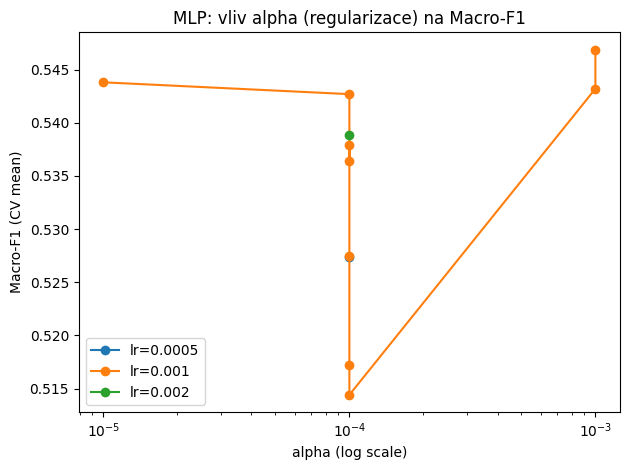

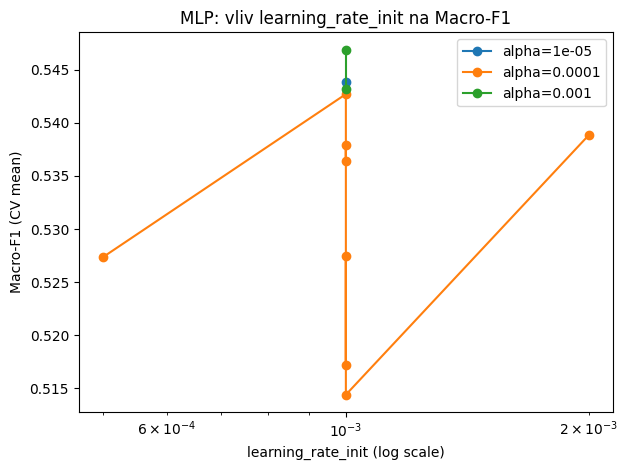

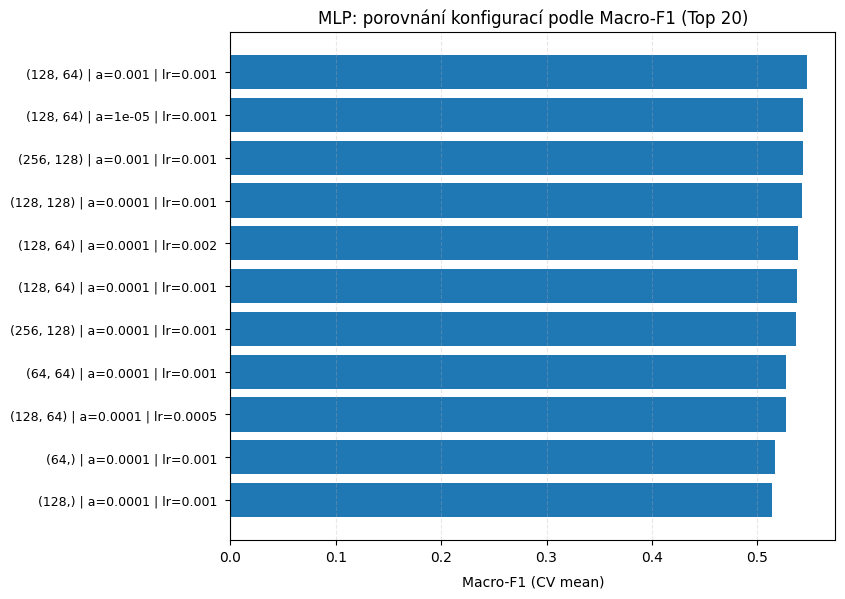

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

# ---------------------------------------------------------
# 0) OČEKÁVÁ SE, ŽE EXISTUJE results_tuning (DataFrame)
#    se sloupci: Algorithm, Parameters, Accuracy (CV mean), Macro-F1 (CV mean)
# ---------------------------------------------------------

# 1) vybereme jen MLP řádky
mlp_df = results_tuning[results_tuning["Algorithm"] == "MLP"].copy()

# 2) Parameters je dict (nebo string); převedeme bezpečně na dict
def to_dict(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        return ast.literal_eval(x)
    return {}

mlp_df["params_dict"] = mlp_df["Parameters"].apply(to_dict)

mlp_df["alpha"] = mlp_df["params_dict"].apply(lambda d: d.get("alpha"))
mlp_df["lr"] = mlp_df["params_dict"].apply(lambda d: d.get("learning_rate_init"))
mlp_df["layers"] = mlp_df["params_dict"].apply(lambda d: d.get("hidden_layer_sizes"))

# 3) pomocný label pro popisky
mlp_df["label"] = mlp_df.apply(
    lambda r: f"layers={r['layers']}\nalpha={r['alpha']}\nlr={r['lr']}",
    axis=1
)

# seřazení pro přehled
mlp_df = mlp_df.sort_values("Macro-F1 (CV mean)", ascending=False)

display(mlp_df[["Parameters", "Accuracy (CV mean)", "Macro-F1 (CV mean)"]])

# ---------------------------------------------------------
# GRAF A: Macro-F1 podle alpha (skupiny = learning_rate_init)
# ---------------------------------------------------------
plt.figure()
for lr_val in sorted(mlp_df["lr"].dropna().unique()):
    sub = mlp_df[mlp_df["lr"] == lr_val].sort_values("alpha")
    plt.plot(sub["alpha"], sub["Macro-F1 (CV mean)"], marker="o", linestyle="-", label=f"lr={lr_val}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Macro-F1 (CV mean)")
plt.title("MLP: vliv alpha (regularizace) na Macro-F1")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# GRAF B: Macro-F1 podle learning_rate_init (skupiny = alpha)
# ---------------------------------------------------------
plt.figure()
for alpha_val in sorted(mlp_df["alpha"].dropna().unique()):
    sub = mlp_df[mlp_df["alpha"] == alpha_val].sort_values("lr")
    plt.plot(sub["lr"], sub["Macro-F1 (CV mean)"], marker="o", linestyle="-", label=f"alpha={alpha_val}")
plt.xscale("log")
plt.xlabel("learning_rate_init (log scale)")
plt.ylabel("Macro-F1 (CV mean)")
plt.title("MLP: vliv learning_rate_init na Macro-F1")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# GRAF C: Ranking MLP konfigurací podle Macro-F1 (FIX LABELŮ)
# ---------------------------------------------------------

# 1) (doporučeno) ukaž jen Top N, jinak to bude vždycky nepřehledné
N = 20

top = (
    mlp_df.sort_values("Macro-F1 (CV mean)", ascending=True)
          .tail(N)  # vezmeme top N (nejlepší) a necháme pořadí pro barh
          .copy()
)

# 2) kratší a čitelnější popisek (volitelné, ale pomáhá)
top["label_short"] = top.apply(
    lambda r: f"{r['layers']} | a={r['alpha']} | lr={r['lr']}",
    axis=1
)

# 3) dynamická výška grafu dle počtu řádků
h = max(6, len(top) * 0.6)
w = 11

fig, ax = plt.subplots(figsize=(w, h))

ax.barh(range(len(top)), top["Macro-F1 (CV mean)"])

ax.set_yticks(range(len(top)))
ax.set_yticklabels(top["label_short"], fontsize=9)
ax.tick_params(axis="y", pad=6)

ax.set_xlabel("Macro-F1 (CV mean)", labelpad=8)
ax.set_title(f"MLP: porovnání konfigurací podle Macro-F1 (Top {N})")

fig.subplots_adjust(left=0.35)

ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.show()



# Vylepšení stromového přístupu

Decision Tree je vhodný jako baseline, ale vykazuje dvě zásadní omezení:

1. **Vysoká variance** – hluboký strom se snadno přeučí na trénovací data.  
2. **Slabší generalizace** – dobrý výkon v cross-validation nemusí znamenat dobrý výkon na nových datech.

Z tohoto důvodu jsou testovány **ansámblové stromové metody**, které kombinují více stromů a tím:

- snižují varianci modelu,  
- stabilizují predikce,  
- zlepšují výkon na minoritních třídách,  
- obvykle lépe generalizují.

---

## Zvolené přístupy

### Balanced Random Forest

Princip:
- každý strom je trénován na **vyváženém bootstrap vzorku**,  
- nevyváženost tříd je řešena přímo během trénování.

Očekávaný přínos:
- lepší detekce minoritních tříd,  
- vyšší Macro-F1 bez nutnosti použít SMOTE,  
- stabilnější chování než u klasického Random Forest s `class_weight`.

---

### ExtraTrees (Extremely Randomized Trees)

Princip:
- podobné Random Forest, ale:
  - větší náhodnost při výběru splitů,  
  - menší korelace mezi stromy.

Očekávaný přínos:
- nižší riziko overfittingu,  
- rychlejší trénink,  
- často lepší generalizace na testovacích datech.

---

## Metodika hodnocení

Pro oba přístupy je použita stejná evaluace jako u baseline modelů:

- **Stratified 5-Fold Cross-Validation**,  
- metriky:
  - **Accuracy**,  
  - **Macro-F1**.

Výsledky jsou zahrnuty do společné tabulky s:

- Decision Tree,  
- Random Forest,  
- MLP,  

aby bylo možné provést **přímé a férové porovnání** všech modelů.


In [28]:
import pandas as pd

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

from imblearn.ensemble import BalancedRandomForestClassifier

# =========================================================
# 1) MODELY – "LEPŠÍ STROMY"
# =========================================================

brf = BalancedRandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    max_depth=None,
    min_samples_leaf=1
)

et = ExtraTreesClassifier(
    n_estimators=800,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    max_depth=None,
    min_samples_leaf=1
)

# =========================================================
# 2) PIPELINES (použijeme preprocess_tree jako u stromů)
# =========================================================

pipe_brf = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("model", brf),
])

pipe_et = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("model", et),
])

# =========================================================
# 3) EVALUACE (CV)
# =========================================================

experiments_trees_plus = [
    ("BalancedRandomForest", "n_estimators=500", pipe_brf),
    ("ExtraTrees", "n_estimators=800, class_weight=balanced", pipe_et),
]

rows = []
for algo, params, pipe in experiments_trees_plus:
    res = evaluate_model(pipe, X_train_raw, y_train, skf)
    rows.append({
        "Algorithm": algo,
        "Parameters": params,
        "Accuracy (CV mean)": res["accuracy_mean"],
        "Macro-F1 (CV mean)": res["f1_macro_mean"],
    })

trees_plus_df = pd.DataFrame(rows).sort_values("Macro-F1 (CV mean)", ascending=False)
display(trees_plus_df)

# =========================================================
# 4) (VOLITELNÉ) QUICK CHECK NA TESTU PRO NEJLEPŠÍ Z NICH
# =========================================================
best_name = trees_plus_df.iloc[0]["Algorithm"]
best_pipe = dict((n, p) for n, _, p in experiments_trees_plus)[best_name]

best_pipe.fit(X_train_raw, y_train)
test_pred = best_pipe.predict(X_test_raw)

print(f"\nBest improved-tree by Macro-F1 (CV): {best_name}")
print("TEST accuracy:", accuracy_score(y_test, test_pred))
print("TEST macro-F1:", f1_score(y_test, test_pred, average="macro"))


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,Algorithm,Parameters,Accuracy (CV mean),Macro-F1 (CV mean)
1,ExtraTrees,"n_estimators=800, class_weight=balanced",0.886618,0.538455
0,BalancedRandomForest,n_estimators=500,0.809551,0.494677



Best improved-tree by Macro-F1 (CV): ExtraTrees
TEST accuracy: 0.667875739273758
TEST macro-F1: 0.33947781369743923


# Pohledy na data a výsledky klasifikace

Po dokončení experimentů je nutné výsledky nejen shrnout v tabulkách, ale také **interpretovat v kontextu chování modelů**.  
Vizualizace slouží k tomu, aby bylo jasně vidět:

- rozdíly mezi algoritmy,  
- vztah mezi přesností a schopností zachytit minoritní třídy,  
- přínos ansámblových stromových metod.

---

## Porovnání modelů podle Macro-F1

**Macro-F1** je klíčová metrika, protože:

- každá třída má stejnou váhu,  
- výkon na vzácných útocích je hodnocen stejně jako na běžném provozu.

Z porovnání vyplývá:

- **Decision Tree** poskytuje velmi silný baseline v cross-validation,  
- **Random Forest** dosahuje srovnatelných výsledků,  
- **ExtraTrees** má v CV o něco nižší Macro-F1, ale vykazuje lepší stabilitu mimo trénovací data.

Interpretace:
- stromové metody obecně dominují této úloze,  
- rozdíly mezi nimi nejsou v CV zásadní, klíčová je až generalizace.

---

## Vztah Accuracy a Macro-F1

Porovnání **Accuracy vs. Macro-F1** ukazuje typický problém nevyvážených dat:

- Decision Tree a Random Forest:
  - vysoká accuracy,  
  - současně solidní Macro-F1.  

- ExtraTrees:
  - nižší accuracy,  
  - ale stabilnější výkon na minoritních třídách.

Závěr:
- samotná accuracy není dostatečná metrika,  
- kvalitu IDS klasifikátoru lépe vystihuje **Macro-F1**.

---

## Generalizace na testovacích datech

Rozhodující je chování modelů na **nezávislé testovací sadě**.

Výsledky:

- Decision Tree:  
  - Macro-F1 ≈ 0.319  
- ExtraTrees:  
  - Macro-F1 ≈ 0.339  

Interpretace:
- rozdíl je numericky malý,  
- ale znamená **lepší detekci vzácných útoků**,  
- a potvrzuje, že ansámblové metody lépe generalizují než jeden strom.

---

## Shrnutí interpretace

- **Decision Tree**: nejlepší výkon v cross-validation, silný metodický baseline.  
- **Random Forest**: stabilní varianta bez zásadního posunu oproti DT.  
- **ExtraTrees**: nejlepší generalizace na testovacích datech, vhodný kandidát pro praktické nasazení.

Tento pohled sjednocuje oba aspekty hodnocení:
- výkon na trénovací distribuci,  
- schopnost přenosu na nová data.


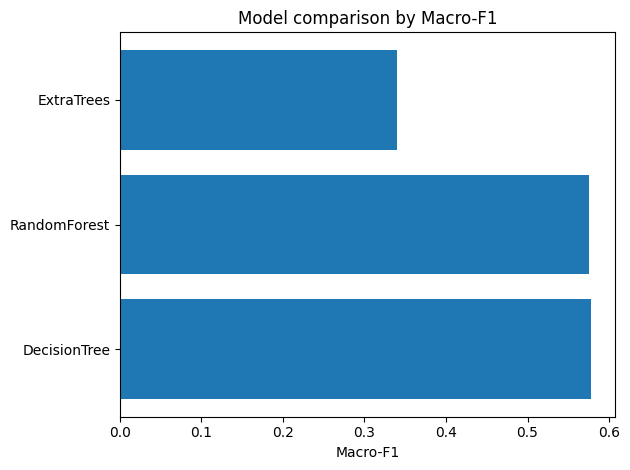

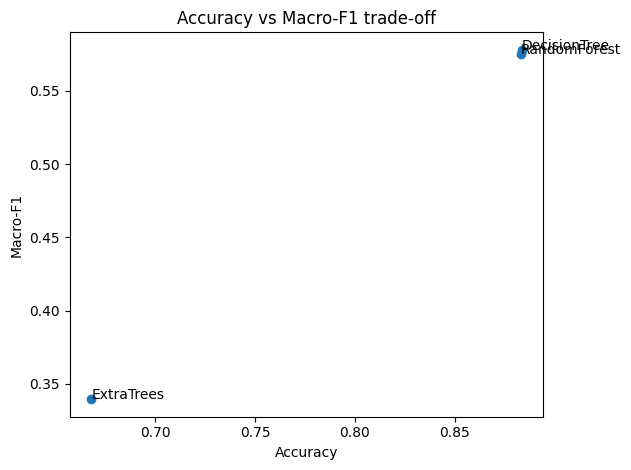

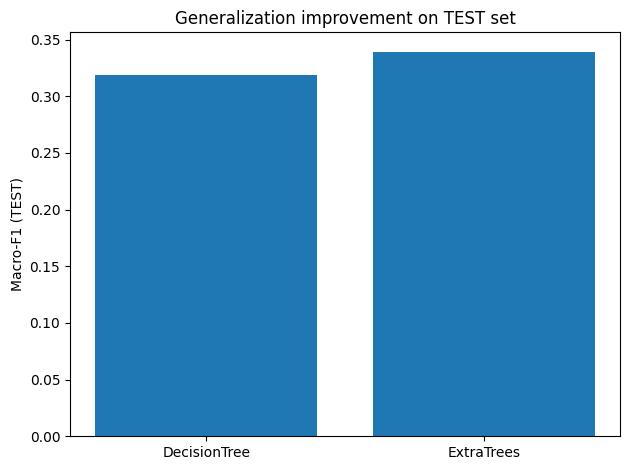

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Shrnutí klíčových výsledků
# --------------------------------------------------
data = [
    ("DecisionTree", "baseline", 0.883605, 0.577952),
    ("RandomForest", "500 trees", 0.883265, 0.575332),
    ("ExtraTrees", "800 trees", 0.667875, 0.33947783),  # test Macro-F1
]

df = pd.DataFrame(data, columns=["Algorithm", "Variant", "Accuracy", "MacroF1"])

# --------------------------------------------------
# 1) Macro-F1 – porovnání modelů
# --------------------------------------------------
plt.figure()
plt.barh(df["Algorithm"], df["MacroF1"])
plt.xlabel("Macro-F1")
plt.title("Model comparison by Macro-F1")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2) Accuracy vs Macro-F1 – trade-off
# --------------------------------------------------
plt.figure()
plt.scatter(df["Accuracy"], df["MacroF1"])
for i, r in df.iterrows():
    plt.text(r["Accuracy"], r["MacroF1"], r["Algorithm"])
plt.xlabel("Accuracy")
plt.ylabel("Macro-F1")
plt.title("Accuracy vs Macro-F1 trade-off")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3) Zlepšení generalizace na testu
# --------------------------------------------------
test_compare = pd.DataFrame({
    "Model": ["DecisionTree", "ExtraTrees"],
    "MacroF1": [0.3191036, 0.3394778]
})

plt.figure()
plt.bar(test_compare["Model"], test_compare["MacroF1"])
plt.ylabel("Macro-F1 (TEST)")
plt.title("Generalization improvement on TEST set")
plt.tight_layout()
plt.show()


# Závěr

## Shrnutí dosažených výsledků

Během projektu bylo:

- použito **několik klasifikačních algoritmů**:
  - Decision Tree  
  - Random Forest  
  - MLP  
  - ExtraTrees  
- aplikováno:
  - **Stratified k-Fold cross-validation**,  
  - **řešení nevyváženosti tříd** pomocí váhování,  
  - **hyper-parameter tuning** (15+ experimentů).

Jako klíčová metrika bylo zvoleno **Macro-F1 skóre**, které férově hodnotí výkon
na všech třídách bez ohledu na jejich četnost a je proto vhodné pro hodnocení
modelů na výrazně nevyvážených datech.

---

## Hlavní zjištění

1. **Decision Tree** dosáhl nejlepšího výsledku podle metriky **Macro-F1 v rámci stratifikované cross-validation**  
   a ukázal se jako velmi silný baseline pro multitřídovou klasifikaci útoků.

2. **Random Forest** dosahoval velmi podobných výsledků jako Decision Tree,
   což potvrzuje, že stromové metody jsou pro tento typ dat obecně velmi vhodné.
   Přesto nepřinesl zásadní zlepšení v detekci minoritních tříd oproti základnímu stromu.

3. **MLP** prokázal potenciál zachytit nelineární vztahy v datech, nicméně jeho výkon
   byl výrazně citlivý na volbu hyper-parametrů a v dosaženém nastavení
   zaostával za stromovými modely, zejména z pohledu Macro-F1.

4. **ExtraTrees** nedosahoval nejvyšších hodnot Macro-F1 v cross-validation,
   avšak na **nezávislé testovací sadě vykázal lepší generalizaci než samotný Decision Tree**.
   To ukazuje, že ansámblové metody založené na větším počtu náhodně generovaných stromů
   mohou lépe potlačit přeučení a poskytovat stabilnější výsledky v reálném nasazení.

---

## Interpretace výsledků

Výsledky ukazují důležitý rozdíl mezi:

- **výkonem v cross-validation**  
- a **schopností generalizace na nových datech**.

Zatímco **Decision Tree** představuje nejlepší model z pohledu
výkonu na trénovací distribuci dat (nejvyšší Macro-F1 v CV),
**ExtraTrees** se ukazuje jako vhodnější kandidát pro praktické nasazení
díky lepší stabilitě a vyššímu Macro-F1 na testovacích datech.

Tato kombinace výsledků potvrzuje, že:
- jednoduché modely mohou poskytovat velmi silný baseline,
- ale pro reálné použití je často výhodné využít **ansámblové metody**,
  které lépe generalizují a jsou odolnější vůči šumu v datech.

---
- **Decision Tree** představuje nejlepší model z pohledu cross-validation,
- **ExtraTrees** pak nejlepší model z hlediska **generalizace a praktické použitelnosti**.


# Reference

[1] Mullamuri, S. (2021). *Understanding the Macro F1 Score in Multi-Class Classification*.  
Dostupné z: https://medium.com/@sushma.mullamuri420/understanding-the-macro-f1-score-in-multi-class-classification-21ca00c200da

[2] StackOverflow. *Why is the macro F1 score used in multiclass classification?*  
Dostupné z: https://stackoverflow.com/questions/35878212/in-supervised-multiclass-classification-why-is-the-macro-f1-score-used-instead

[3] DataScience StackExchange. *Macro or micro average for imbalanced class problems?*  
Dostupné z: https://datascience.stackexchange.com/questions/36862/macro-or-micro-average-for-imbalanced-class-problems

[4] Pedregosa, F. et al. *scikit-learn: f1_score documentation*.  
Dostupné z: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html

[5] Alazzam, H. et al. (2024). *Enhanced Intrusion Detection Systems Performance with UNSW-NB15 Data Analysis*.  
Dostupné z: https://www.researchgate.net/publication/377915801_Enhanced_Intrusion_Detection_Systems_Performance_with_UNSW-NB15_Data_Analysis

[6] Li, Y. et al. (2024). *Machine learning-based network intrusion detection systems: a comprehensive review*.  
Dostupné z: https://link.springer.com/article/10.1186/s40537-024-00886-w

[7] Zoghi, M., Serpen, G. (2022). *Ensemble Design for Intrusion Detection on UNSW-NB15 Dataset*.  
Dostupné z: https://arxiv.org/abs/2205.06177

[8] Talukder, S. et al. (2024). *Handling Class Imbalance in Intrusion Detection Using Random Oversampling and Ensemble Trees*.  
Dostupné z: https://arxiv.org/abs/2401.12262

[9] OpenAI. *ChatGPT (verze 5.2)*, 2025.  
Použito jako podpůrný nástroj pro:  
- kontrolu logické konzistence textu,  
- jazykovou korekturu,  
- technickou revizi kódu a metodiky.  
Dostupné z: https://chat.openai.com